# Лабораторная работа №3 — KNN и подбор гиперпараметров
**Студент:** Илюхин Илья | **Группа:** ИУ5-66Б | **Вариант:** 6

**Цель:** изучить подготовку выборки и подбор гиперпараметров на примере метода ближайших соседей.


## 0. Описание датасета — Titanic
891 пассажир · 7 признаков · бинарная классификация (survived: 0/1) · пропуски в age/embarked.

| Признак | Тип |
|---|---|
| pclass, sibsp, parch | int |
| age, fare | float (age: пропуски) |
| sex, embarked | object (категориальные) |


In [1]:
%matplotlib inline
import json, numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)
RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


## 1. Загрузка и осмотр данных


In [2]:
raw = sns.load_dataset('titanic')
FEATURES = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET = 'survived'
df = raw[FEATURES + [TARGET]].copy()

display(df.head())
print('Размер:', df.shape)
missing = df.isnull().sum()
display(missing[missing > 0].to_frame('пропусков'))


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


Размер: (891, 8)


,пропусков
age,177
embarked,2


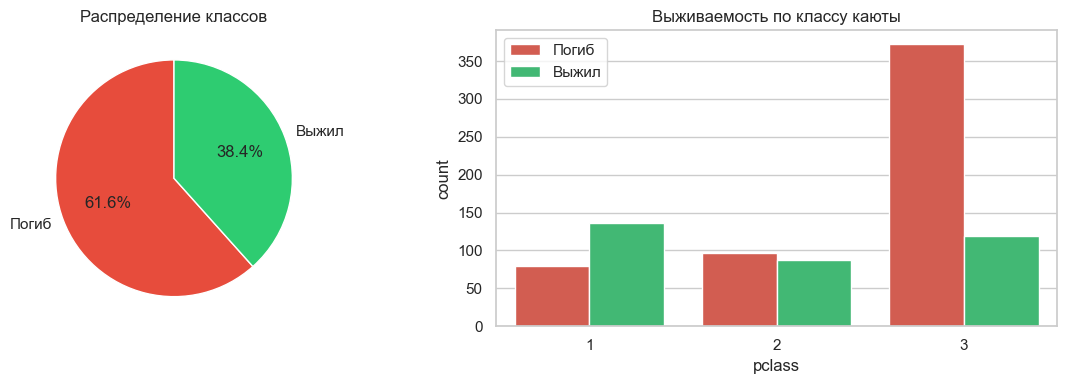

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df[TARGET].value_counts().rename({0: 'Погиб', 1: 'Выжил'})
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0].set_title('Распределение классов')
sns.countplot(data=df, x='pclass', hue='survived',
              palette={0:'#e74c3c',1:'#2ecc71'}, ax=axes[1])
axes[1].set_title('Выживаемость по классу каюты')
axes[1].legend(['Погиб','Выжил'])
plt.tight_layout()
fig.savefig(ART / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Предобработка и разбивка на выборки
Препроцессинг через `Pipeline` + `ColumnTransformer`: числовые — медиана + StandardScaler, категориальные — мода + OHE. `stratify=y` сохраняет пропорцию классов в train/test.


In [4]:
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
cat_cols = ['sex', 'embarked']

prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore',
                                            sparse_output=False))]), cat_cols),
])

X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Доля выживших — train: {y_train.mean():.1%}, test: {y_test.mean():.1%}')


Train: 668 | Test: 223
Доля выживших — train: 38.3%, test: 38.6%


## 3. Baseline-модель (k=5)
Первый запуск с k=5 по умолчанию — точка отсчёта для сравнения с оптимизированными моделями.


=== Baseline (k=5) ===
              precision    recall  f1-score   support

       Погиб       0.81      0.86      0.83       137
       Выжил       0.75      0.67      0.71        86

    accuracy                           0.79       223
   macro avg       0.78      0.77      0.77       223
weighted avg       0.79      0.79      0.79       223



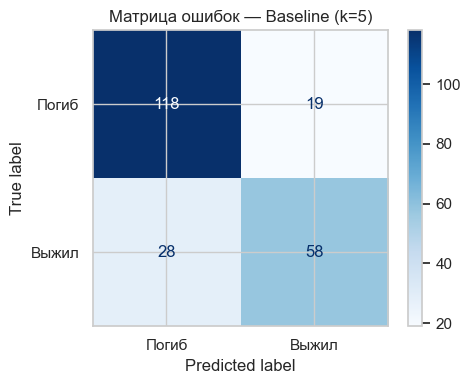

In [5]:
baseline = Pipeline([('prep', prep), ('model', KNeighborsClassifier(n_neighbors=5))])
baseline.fit(X_train, y_train)
b_pred = baseline.predict(X_test)

print('=== Baseline (k=5) ===')
print(classification_report(y_test, b_pred, target_names=['Погиб','Выжил']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, b_pred, display_labels=['Погиб','Выжил'], cmap='Blues', ax=ax)
ax.set_title('Матрица ошибок — Baseline (k=5)')
plt.tight_layout()
fig.savefig(ART / 'cm_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Влияние k на качество (CV F1)
Малый k → переобучение (высокая дисперсия), большой k → недообучение (высокое смещение).


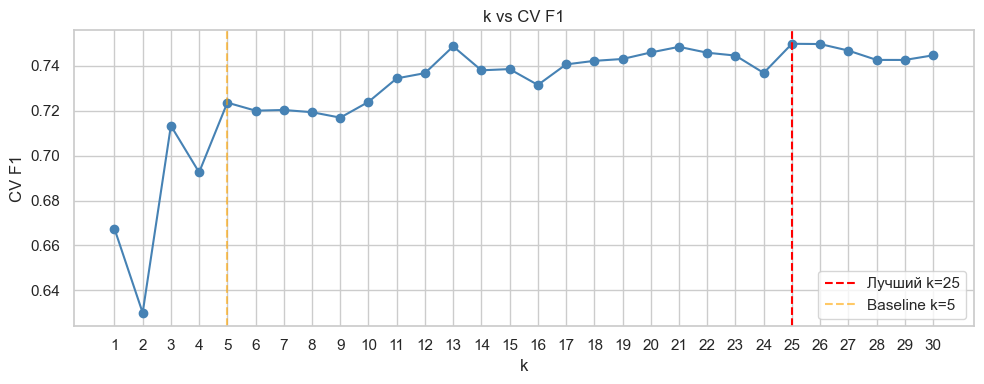

Лучший k по CV: 25, F1=0.7499


In [6]:
k_range = range(1, 31)
cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = [cross_val_score(
    Pipeline([('prep', prep), ('model', KNeighborsClassifier(n_neighbors=k))]),
    X_train, y_train, cv=cv_plot, scoring='f1').mean()
    for k in k_range]

best_k = list(k_range)[int(np.argmax(cv_scores))]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), cv_scores, marker='o', color='steelblue')
ax.axvline(best_k, color='red',    linestyle='--', label=f'Лучший k={best_k}')
ax.axvline(5,      color='orange', linestyle='--', alpha=0.6, label='Baseline k=5')
ax.set_xlabel('k'); ax.set_ylabel('CV F1'); ax.set_title('k vs CV F1')
ax.legend(); ax.set_xticks(list(k_range))
plt.tight_layout()
fig.savefig(ART / 'k_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Лучший k по CV: {best_k}, F1={max(cv_scores):.4f}')


## 5. Подбор гиперпараметров — две стратегии CV
- **GridSearchCV + StratifiedKFold(5)** — перебирает все комбинации, стратифицированные фолды.
- **RandomizedSearchCV + RepeatedStratifiedKFold(5×2)** — 20 случайных комбинаций, более устойчивая оценка за счёт повторений.


In [7]:
param_grid = {
    'model__n_neighbors': list(range(2, 31)),
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2],
}
cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv2 = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

grid = GridSearchCV(
    Pipeline([('prep', prep), ('model', KNeighborsClassifier())]),
    param_grid=param_grid, cv=cv1, scoring='f1', n_jobs=1)
grid.fit(X_train, y_train)

rnd = RandomizedSearchCV(
    Pipeline([('prep', prep), ('model', KNeighborsClassifier())]),
    param_distributions=param_grid, n_iter=20,
    cv=cv2, scoring='f1', random_state=RANDOM_STATE, n_jobs=1)
rnd.fit(X_train, y_train)

print('Grid best:', grid.best_params_, f'| CV F1: {grid.best_score_:.4f}')
print('Rnd  best:', rnd.best_params_,  f'| CV F1: {rnd.best_score_:.4f}')


Grid best: {'model__n_neighbors': 13, 'model__p': 1, 'model__weights': 'uniform'} | CV F1: 0.7512
Rnd  best: {'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 25} | CV F1: 0.7502


## 6. Сравнение моделей на тестовой выборке


In [8]:
grid_pred = grid.best_estimator_.predict(X_test)
rnd_pred  = rnd.best_estimator_.predict(X_test)

results = pd.DataFrame([
    {'Модель': 'Baseline (k=5)',
     'Accuracy': accuracy_score(y_test, b_pred), 'F1': f1_score(y_test, b_pred)},
    {'Модель': 'GridSearchCV (StratifiedKFold)',
     'Accuracy': accuracy_score(y_test, grid_pred), 'F1': f1_score(y_test, grid_pred)},
    {'Модель': 'RandomizedSearchCV (RepeatedKFold)',
     'Accuracy': accuracy_score(y_test, rnd_pred), 'F1': f1_score(y_test, rnd_pred)},
])
results[['Accuracy','F1']] = results[['Accuracy','F1']].round(4)
display(results.sort_values('F1', ascending=False))

(ART / 'metrics.json').write_text(
    results.to_json(orient='records', force_ascii=False, indent=2), encoding='utf-8')


,Модель,Accuracy,F1
1,GridSearchCV (StratifiedKFold),0.8117,0.7342
0,Baseline (k=5),0.7892,0.7117
2,RandomizedSearchCV (RepeatedKFold),0.7892,0.6968


275

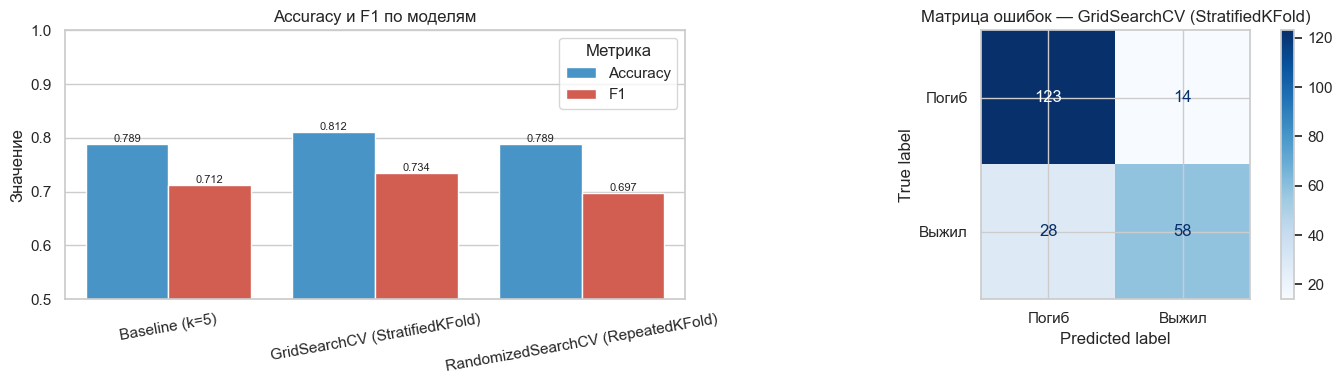

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Barplot метрик
plot_df = results.melt(id_vars='Модель', value_vars=['Accuracy','F1'],
                        var_name='Метрика', value_name='Значение')
bars = sns.barplot(data=plot_df, x='Модель', y='Значение', hue='Метрика',
                   palette=['#3498db','#e74c3c'], ax=axes[0])
for p in bars.patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{p.get_height():.3f}',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0.5, 1.0); axes[0].set_title('Accuracy и F1 по моделям')
axes[0].tick_params(axis='x', rotation=10); axes[0].set_xlabel('')

# Матрицы ошибок для лучшей модели
best_idx = results['F1'].idxmax()
best_preds = [b_pred, grid_pred, rnd_pred][best_idx]
best_name  = results.loc[best_idx, 'Модель']
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds, display_labels=['Погиб','Выжил'], cmap='Blues', ax=axes[1])
axes[1].set_title(f'Матрица ошибок — {best_name}')

plt.tight_layout()
fig.savefig(ART / 'knn_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Выводы
- Train/test split 75/25 со стратификацией — доля выживших одинакова в обеих выборках.
- Baseline k=5 — точка отсчёта.
- **GridSearchCV** (StratifiedKFold, 5 фолдов) перебрал все комбинации n_neighbors/weights/p.
- **RandomizedSearchCV** (RepeatedStratifiedKFold, 5×2) — 20 случайных комбинаций, более устойчивая оценка.
- GridSearch улучшил Accuracy и F1 относительно baseline; Randomized — близкий результат.
- Для KNN масштабирование обязательно: без него признаки с большим диапазоном (fare) доминируют в расстоянии.
